# Assignment 3: Data Exploration
```
Course: ENV 700 - Environmental Data Exploration
Author: Maya Schroder
Date: Fall 2026
```

This notebook accompanies the Python lessons on **Data Exploration**, the first stage in the data analytics pipeline: **exploration, wrangling, analysis, and visualization**.


Use this notebook to explore the `NEON_NIWO_Litter_massdata_2016-26_raw.csv` dataset. 
1. Data Provenance: Answer questions regarding the dataset by referring to its metadata document.
1. Set up your notebook: Import packages, set data paths, set file paths
1. Import the dataset into a dataframe and inspect its properties
1. Reassign data types as needed
1. Examine the data for any missing values
1. Examine the distribution of values in the dataset, noting any extreme or unusual values
1. Explore any patterns in the data

---
## 1. Data Provenance

The Niwot Ridge litter and woody debris dataset was collected from the National Ecological Observatory Network, which collectively includes 81 aquatic and terrestrial sites across 20 ecoclimatic domains. 32 of these sites sample forest litter and woody debris, and we will focus on the Niwot Ridge long-term ecological research (LTER) station in Colorado. 

Why might we be interested in studying litter and woody debris that falls to the ground in forests? Feel free to do a brief internet search if you feel you need more background information. (AI is allowed here, but put answers in your own words.)

>Answer: Litter and woody debris can help understand the health of the forest and the nutrients contained in the debris. Additionally, sampling debris on forest floors allows for understanding of fire preparation and fire risks. If forest floors are likely to spread a wildfire, it is helpful to know this ahead of time and warn forest visitors to practice safe clean up when visiting.

---
## 2. Set up your Python session

Load the necessary packages, check your current working directory, and import the Niwot Ridge NEON litter and woody debris dataset: `NEON_NIWO_Litter_massdata_2016-26_raw.csv`

Name  dataframes `Litter`.

**Be sure to:**

- Use `pathlib.Path` to specify project-relative paths to your datasets.
- Convert appropriate character-based columns to the Pandas `category` dtype.
- Print or otherwise confirm the paths to each filename.
- Display the first 5 rows of each dataframe.

### ✅ 2.1 Import packages
* Load the pathlib Path object and the Pandas package into your coding environnment

In [75]:
from pathlib import Path
import pandas as pd

### ✅ 2.2 Set project folders using relative paths
* Create two Path variables, one set to your project's root folder and another to the raw data folder. 
* Display the the values of these two variables in your notebook.

In [76]:
root_fldr = Path.cwd().parent
raw_fldr = root_fldr / 'data' / 'raw'

print(root_fldr)
print(raw_fldr)

c:\Users\mis32\ENV700
c:\Users\mis32\ENV700\data\raw


### ✅ 2.3 Set a path to the raw data file
* Create a Path variable pointing to the `NEON_NIWO_Litter_massdata_2016-26_raw.csv` file. 
* Confirm that the file exists at the path specified. 

In [77]:
raw_data = raw_fldr / 'NEON_NIWO_Litter_massdata_2016-26_raw.csv'
print(raw_data.exists())

True


### ✅ 2.4 Import the data
* Import the CSV file as a dataframe named `Litter`.
* Display the first 5 rows of the dataframe.

In [78]:
Litter = pd.read_csv(
    raw_data,
    dtype={
        'uid':'category',
        'domainID':'category',
        'siteID':'category',
        'plotID':'category',
        'trapID':'category',
        'eventID':'category',
        'fieldSampleID':'category',
        'massSampleID':'category',
        'functionalGroup':'category'
    },
    parse_dates=["weighDate","setDate","collectDate", "ovenStartDate", "ovenEndDate"]
)

Litter.head()

,uid,namedLocation,domainID,siteID,plotID,trapID,weighDate,setDate,collectDate,eventID,...,massSampleID,samplingProtocolVersion,biogeoSample,functionalGroup,dryMass,qaDryMass,remarks,measuredBy,publicationDate,release
0,907e663c-b899-4801-b477-d5effa28bd7b,NIWO_047.basePlot.ltr,D13,NIWO,NIWO_047,NIWO_047_197,2016-06-22,2015-09-29,2016-06-16,LTR.2016.NIWO.01,...,NEON.LTR.NIWO047197.20160616.FLR,NEON.DOC.001710vE,N,Flowers,0.01,N,NaN,jlinden@field-ops.org,20251204T230619Z,RELEASE-2026
1,8c01e181-8bfb-4f66-ab4e-e76fd291ca48,NIWO_047.basePlot.ltr,D13,NIWO,NIWO_047,NIWO_047_197,2016-06-22,2015-09-29,2016-06-16,LTR.2016.NIWO.01,...,NEON.LTR.NIWO047197.20160616.LVS,NEON.DOC.001710vE,N,Leaves,0.00,N,no sample to collect,jlinden@field-ops.org,20251204T230619Z,RELEASE-2026
2,8a69528e-5d64-4601-ae19-3e2ae57eb20c,NIWO_047.basePlot.ltr,D13,NIWO,NIWO_047,NIWO_047_197,2016-06-22,2015-09-29,2016-06-16,LTR.2016.NIWO.01,...,NEON.LTR.NIWO047197.20160616.NDL,NEON.DOC.001710vE,N,Needles,0.54,N,NaN,jlinden@field-ops.org,20251204T230619Z,RELEASE-2026
3,154c966e-e66e-4450-b7ba-c43733562863,NIWO_061.basePlot.ltr,D13,NIWO,NIWO_061,NIWO_061_169,2016-06-22,2015-09-29,2016-06-16,LTR.2016.NIWO.01,...,NEON.LTR.NIWO061169.20160616.LVS,NEON.DOC.001710vE,N,Leaves,0.00,N,no sample to collect,jlinden@field-ops.org,20251204T230619Z,RELEASE-2026
4,a8887a79-49ea-4a6c-bb9b-2004b7474287,NIWO_062.basePlot.ltr,D13,NIWO,NIWO_062,NIWO_062_050,2016-06-22,2015-09-29,2016-06-16,LTR.2016.NIWO.01,...,NEON.LTR.NIWO062050.20160616.OTH,NEON.DOC.001710vE,N,Other,0.58,N,NaN,jlinden@field-ops.org,20251204T230619Z,RELEASE-2026


### ✅ 2.5 Examine your dataframe
* From just looking at the data, enter a single field name that appears to fit the indicated description. If there are none that fit that column, just enter "None".

> List a **categorical** column: domainID

> List a **date** column: weighDate

> List a **floating point** column: dryMass

> List a **string** column: measuredBy

> List a **Boolean** column: None

---
## 3. Explore the structure of your dataframe
* Use the most appropriate dataframe property or method for each question. 

#### ✅ 3.1 Reveal the dimensions (# of rows and columns) of your dataframe

In [79]:
Litter.shape

(4443, 25)

#### ✅ 3.2 List the names of the columns in the dataframe. 

In [80]:
Litter.columns

Index(['uid', 'namedLocation', 'domainID', 'siteID', 'plotID', 'trapID',
       'weighDate', 'setDate', 'collectDate', 'eventID', 'ovenStartDate',
       'ovenEndDate', 'fieldSampleID', 'sampleCondition', 'samplePrepMethod',
       'massSampleID', 'samplingProtocolVersion', 'biogeoSample',
       'functionalGroup', 'dryMass', 'qaDryMass', 'remarks', 'measuredBy',
       'publicationDate', 'release'],
      dtype='str')

#### ✅ 3.3 Display information about each column including its name, its datatype, and how many non-null values it contains. 

In [81]:
Litter.info()

<class 'pandas.DataFrame'>
RangeIndex: 4443 entries, 0 to 4442
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   uid                      4443 non-null   category           
 1   namedLocation            4443 non-null   str                
 2   domainID                 4443 non-null   category           
 3   siteID                   4443 non-null   category           
 4   plotID                   4443 non-null   category           
 5   trapID                   4443 non-null   category           
 6   weighDate                3746 non-null   datetime64[us]     
 7   setDate                  4443 non-null   datetime64[us]     
 8   collectDate              4443 non-null   datetime64[us]     
 9   eventID                  4443 non-null   category           
 10  ovenStartDate            3936 non-null   datetime64[us, UTC]
 11  ovenEndDate              3936 non-null   

#### ✅ 3.4 Show summary statistics for each numeric column in the dataframe

In [82]:
Litter.describe()

,weighDate,setDate,collectDate,samplePrepMethod,dryMass
count,3746,4443,4443,0.0,4443.000000
mean,2020-08-10 03:03:44.879871,2020-09-18 01:38:31.681296,2020-12-10 09:45:20.054017,NaN,1.247968
min,2013-09-26 00:00:00,2015-09-26 00:00:00,2016-06-16 00:00:00,NaN,0.000000
25%,2018-07-23 00:00:00,2018-08-02 00:00:00,2018-09-27 00:00:00,NaN,0.000000
50%,2020-08-04 00:00:00,2020-09-22 00:00:00,2020-11-18 00:00:00,NaN,0.010000
75%,2022-09-27 00:00:00,2022-09-19 00:00:00,2023-06-05 00:00:00,NaN,0.410000
max,2024-10-22 00:00:00,2024-09-16 00:00:00,2024-10-14 00:00:00,NaN,145.250000
std,NaN,NaN,NaN,NaN,4.530086


#### ✅ 3.5 Describe one issue with this dataset that is worth mentioning before proceeding with its analysis. 

> Answer: Sample prep method seems to be entirely null values. This could be concerning if we were interested in understanding differences in dry mass by sample prep method.

---
## 4. Reassign data types

#### ✅ 4.1. List the data types of each column

In [83]:
Litter.dtypes

uid                                   category
namedLocation                              str
domainID                              category
siteID                                category
plotID                                category
trapID                                category
weighDate                       datetime64[us]
setDate                         datetime64[us]
collectDate                     datetime64[us]
eventID                               category
ovenStartDate              datetime64[us, UTC]
ovenEndDate                datetime64[us, UTC]
fieldSampleID                         category
sampleCondition                            str
samplePrepMethod                       float64
massSampleID                          category
samplingProtocolVersion                    str
biogeoSample                               str
functionalGroup                       category
dryMass                                float64
qaDryMass                                  str
remarks      

#### ✅ 4.2 Convert the `plotID` column's data type from a "string" to a "category"

> plotID is already a category because I imported is as such. See 2.4 above.

#### ✅ 4.3 Convert the `collectDate` column's data type from a "string" to a "datetime"
* Be sure to set the date format explicitly. 

In [84]:
Litter["collectDate"] = pd.to_datetime(Litter["collectDate"], format="%Y-%m-%d")

#### ✅ 4.4 Show the updated datatypes

In [85]:
Litter.dtypes

uid                                   category
namedLocation                              str
domainID                              category
siteID                                category
plotID                                category
trapID                                category
weighDate                       datetime64[us]
setDate                         datetime64[us]
collectDate                     datetime64[us]
eventID                               category
ovenStartDate              datetime64[us, UTC]
ovenEndDate                datetime64[us, UTC]
fieldSampleID                         category
sampleCondition                            str
samplePrepMethod                       float64
massSampleID                          category
samplingProtocolVersion                    str
biogeoSample                               str
functionalGroup                       category
dryMass                                float64
qaDryMass                                  str
remarks      

#### ✅ 4.5 Reimport the CSV setting the following data types, again saving as a dataframe named `Litter`
* `siteID`, `plotID`, `trapID`, and `functionalGroup` should be imported as categories.
* `weighDate`, `setDate`, and `collectDate` should be imported as dates. Set the date format explicitly. 
* After importing show the dtypes of the dataframe.

In [86]:
Litter = pd.read_csv(
    raw_data,
    dtype={
        'siteID':'category',
        'plotID':'category',
        'trapID':'category',
        'functionalGroup':'category'
    },
    parse_dates=["weighDate","setDate","collectDate"],
    date_format="%Y-%m-%d"
)

Litter.dtypes

uid                                   str
namedLocation                         str
domainID                              str
siteID                           category
plotID                           category
trapID                           category
weighDate                  datetime64[us]
setDate                    datetime64[us]
collectDate                datetime64[us]
eventID                               str
ovenStartDate                         str
ovenEndDate                           str
fieldSampleID                         str
sampleCondition                       str
samplePrepMethod                  float64
massSampleID                          str
samplingProtocolVersion               str
biogeoSample                          str
functionalGroup                  category
dryMass                           float64
qaDryMass                             str
remarks                               str
measuredBy                            str
publicationDate                   

---
## 5. Examine the data for missing values

#### ✅ 5.1 Report the percentage of records in each column that are missing. 
* Present this as a table of all columns listed in descending order of missing values, i.e. the field with the highest percentage of missing values should be listed first. 

In [87]:
missing_pct = (Litter.isna().sum()/4443)*100
missing_pct.sort_values(ascending=False)

samplePrepMethod           100.000000
remarks                     96.286293
measuredBy                  43.574162
sampleCondition             39.927977
weighDate                   15.687598
ovenEndDate                 11.411209
ovenStartDate               11.411209
biogeoSample                 1.643034
samplingProtocolVersion      1.643034
collectDate                  0.000000
setDate                      0.000000
trapID                       0.000000
plotID                       0.000000
domainID                     0.000000
siteID                       0.000000
namedLocation                0.000000
uid                          0.000000
massSampleID                 0.000000
fieldSampleID                0.000000
eventID                      0.000000
functionalGroup              0.000000
qaDryMass                    0.000000
dryMass                      0.000000
publicationDate              0.000000
release                      0.000000
dtype: float64

#### ✅ 5.2 Compare the mean dry mass for all records vs just records that have a known sample condition value
* Create a new dataframe that eliminates rows that are missing values in the `sampleCondition` column. 
* Compute the mean of values in the `dryMass` column for all records.
* Compute the mean of values in the `dryMass` column for just the records having a known sample condition value

In [88]:
Litter_sample_cond = Litter.dropna(subset=["sampleCondition"]).copy()

print("Full data dry mass mean:", Litter["dryMass"].mean())
print("Sample condition complete dry mass mean:", Litter_sample_cond["dryMass"].mean())

Full data dry mass mean: 1.247968039612874
Sample condition complete dry mass mean: 1.325412888722368


---
## 6. Examine the distibution of values

### ✅ 6.1 Create a plot showing how many records occur in each functional group 
* Functional groups = '*Flowers*', '*Leaves*', '*Needles*', etc.
* Sort the bars in order from least to greatest number of records.

<Axes: xlabel='functionalGroup'>

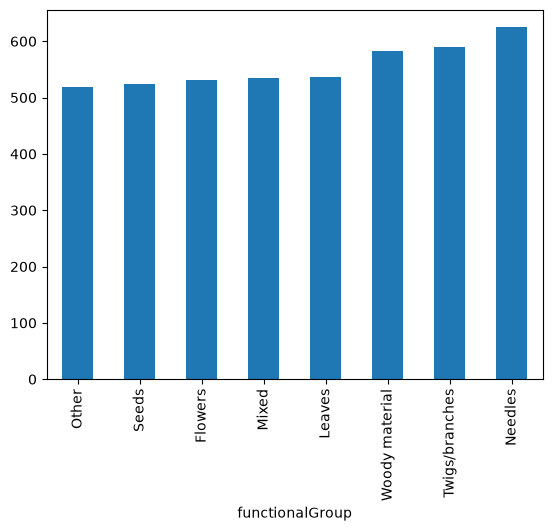

In [89]:
Litter["functionalGroup"].value_counts().sort_values().plot(kind="bar")

### ✅ 6.2 Examine the distribution of dry mass for each functional group
* Create a box plot of dry mass showing a separate box for each functional group. 
* TIP: 
    - Add the argument `vert=False` to rotate the plot 90 degrees for easier reading.
    - Also set the figure width x height to 14 x 5, also to make it more informative.

<Axes: title={'center': 'dryMass'}, ylabel='functionalGroup'>

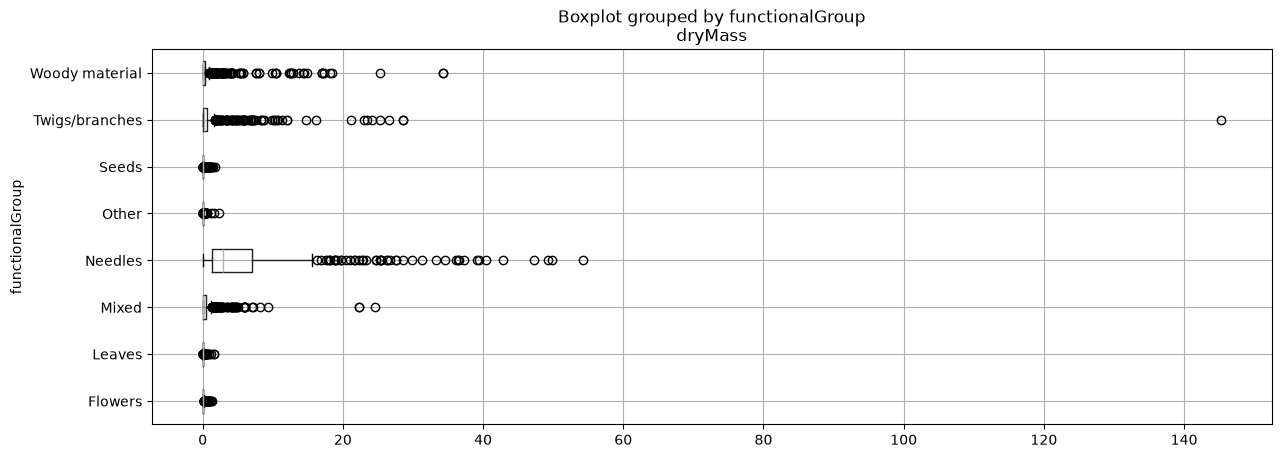

In [90]:
Litter.boxplot(column=["dryMass"], by="functionalGroup", vert=False, figsize=(14,5))

#### 🔸Interpretation
* Which functional group has the highest median dry mass? 

>Answer: Needles

* Which functional group has the highest measured dry mass?

> Answer: Twigs/branches

### ✅ 6.3 Repeat the same plot but omitting the outliers 
* Include the argument `showfliers=False` to omit outliers.

<Axes: title={'center': 'dryMass'}, ylabel='functionalGroup'>

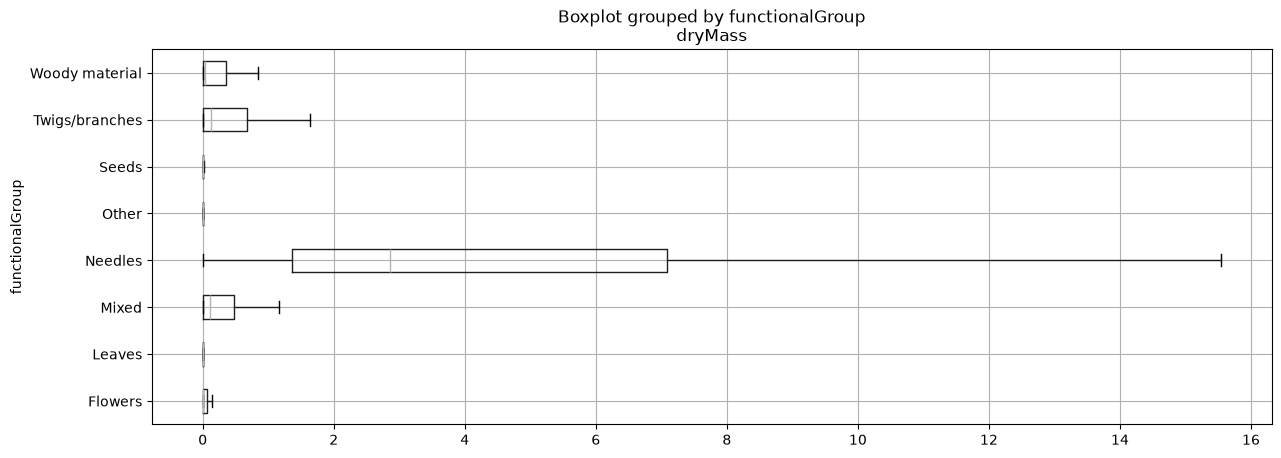

In [91]:
Litter.boxplot(column=["dryMass"], by="functionalGroup", vert=False, figsize=(14,5),showfliers=False)

#### 🔸Interpretation
* Which functional group has the largest inter-quartile range?

> Answer: Needles

## ✳️ Submission
* Check that you have answered all the questions asked.
* Restart your notebook and then run all code cells. 
* Stage and commit the notebook to Git, push to GitHub
* Export your notebook to an HTML document
    - From the `...` item in the notebook menu, select Export, thn HTML
* Submit the PDF to Canvas.